In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv('sovereign_default_dataset_1980_2022.csv - sovereign_default_dataset_1980_2022.csv')

# Select independent variables (features)
X = df[['Debt_GDP', 'Inflation', 'Reserves_months', 'Trade_openness', 
        'US_FedFundsRate', 'ICRG_political', 'fiscal_balance', 
        'DebtServ_XGDP', 'GDP_per_capita_USD', 'ElectionYear']]

# Dependent variable
y = df['Default']

# Train-test split (optional, but recommended)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Results
print("Intercept:", model.intercept_)
print("Coefficients:", dict(zip(X.columns, model.coef_)))
print("R² score on training set:", model.score(X_train, y_train))
print("R² score on test set:", model.score(X_test, y_test))


Intercept: 0.0992891530352962
Coefficients: {'Debt_GDP': 6.748586759052423e-07, 'Inflation': 2.9294534952131293e-05, 'Reserves_months': -0.002003631282569217, 'Trade_openness': -0.0002730125484158281, 'US_FedFundsRate': -0.0018823322313749318, 'ICRG_political': 0.00020193694712507092, 'fiscal_balance': -0.0002447303993166053, 'DebtServ_XGDP': -0.00027864159008252, 'GDP_per_capita_USD': -1.746739891187628e-07, 'ElectionYear': -0.008171277990398306}
R² score on training set: 0.00549676806778554
R² score on test set: -0.008391598430248948


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Independent vars
X = df[['Debt_GDP', 'Inflation', 'Reserves_months', 'Trade_openness', 'US_FedFundsRate']]
y = df['Default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic regression model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Predictions
y_pred = log_model.predict(X_test)

# Evaluation
print("Accuracy on test set:", accuracy_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


Accuracy on test set: 0.9302325581395349
Classification report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96       560
           1       0.00      0.00      0.00        42

    accuracy                           0.93       602
   macro avg       0.47      0.50      0.48       602
weighted avg       0.87      0.93      0.90       602



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [3]:
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("Accuracy on test set:", accuracy_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


Accuracy on test set: 0.5481727574750831
Classification report:
               precision    recall  f1-score   support

           0       0.93      0.56      0.70       560
           1       0.07      0.45      0.12        42

    accuracy                           0.55       602
   macro avg       0.50      0.50      0.41       602
weighted avg       0.87      0.55      0.66       602



In [10]:
mean_debt_gdp = df['Debt_GDP'].mean() * 100



In [12]:
display (mean_debt_gdp)

8426.899060004984

In [13]:
import pandas as pd

# Load dataset
df = pd.read_csv('sovereign_default_dataset_1980_2022.csv - sovereign_default_dataset_1980_2022.csv')

# Define numeric columns (exclude 'Country', 'Year', 'Default' categorical fields)
numeric_cols = [
    'Debt_GDP', 'ExtDebt_GDP', 'DebtServ_XGDP', 'RealGDP_growth', 'GDP_per_capita_USD',
    'Inflation', 'fiscal_balance', 'primary_balance', 'CurrentAccount_GDP', 'Reserves_months',
    'ExchangeRate_change', 'Trade_openness', 'US_FedFundsRate', 'World_GDP_growth',
    'Oil_price_index', 'VIX', 'ICRG_political', 'ElectionYear'
]

# Generate descriptive statistics
desc_stats = df[numeric_cols].describe().T
desc_stats['median'] = df[numeric_cols].median()

# Reorder for readability (optional)
desc_stats = desc_stats[['mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max']]

# Round for APA-style presentation
desc_stats = desc_stats.round(2)

# Print descriptive table
print("\n=== Descriptive Statistics ===")
print(desc_stats)



=== Descriptive Statistics ===
                         mean    median       std     min       25%       50%  \
Debt_GDP                84.27     83.48     37.36   20.00     51.92     83.48   
ExtDebt_GDP             53.80     53.38     25.68   10.02     31.76     53.38   
DebtServ_XGDP           22.63     22.55     10.09    5.00     13.92     22.55   
RealGDP_growth          -0.04     -0.19      5.80   -9.98     -5.13     -0.19   
GDP_per_capita_USD   30519.22  31057.23  17126.94  315.07  16030.38  31057.23   
Inflation               48.71     48.44     30.30   -4.94     23.26     48.44   
fiscal_balance          -2.26     -2.14      7.25  -15.00     -8.60     -2.14   
primary_balance         -2.28     -2.18      7.49  -17.79     -8.59     -2.18   
CurrentAccount_GDP      -0.42     -0.47     11.40  -19.99    -10.26     -0.47   
Reserves_months          6.27      6.27      3.33    0.50      3.32      6.27   
ExchangeRate_change     24.35     25.02     43.20  -50.00    -13.11     25.02

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis

# Load the dataset
df = pd.read_csv('sovereign_default_dataset_1980_2022.csv - sovereign_default_dataset_1980_2022.csv')

# Select only numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns

# Basic statistics
basic_stats = df[numerical_cols].describe().T

# Add skewness and kurtosis
basic_stats['skewness'] = df[numerical_cols].skew()
basic_stats['kurtosis'] = df[numerical_cols].kurtosis()

# Display the full table
pd.set_option('display.max_rows', None)
print(basic_stats)


                      count          mean           std          min  \
Year                 3010.0   2001.000000     12.411736  1980.000000   
Default              3010.0      0.054817      0.227661     0.000000   
Debt_GDP             3010.0     84.268991     37.357464    20.003993   
ExtDebt_GDP          3010.0     53.799457     25.681498    10.021690   
DebtServ_XGDP        3010.0     22.631192     10.094667     5.001849   
RealGDP_growth       3010.0     -0.043286      5.804698    -9.975928   
GDP_per_capita_USD   3010.0  30519.219467  17126.938056   315.071533   
Inflation            3010.0     48.707913     30.299610    -4.935778   
fiscal_balance       3010.0     -2.263917      7.253890   -14.998797   
primary_balance      3010.0     -2.279611      7.492099   -17.787800   
CurrentAccount_GDP   3010.0     -0.421925     11.397178   -19.994994   
Reserves_months      3010.0      6.267717      3.328810     0.500776   
ExchangeRate_change  3010.0     24.354883     43.204348   -49.99

In [4]:
import pandas as pd

# Load the dataset
df = pd.read_csv ('sovereign_default_dataset_1980_2022.csv - sovereign_default_dataset_1980_2022.csv')

# Display descriptive statistics
statistics_summary = df.describe(include='all')

# Show the result
print(statistics_summary)


          Country         Year      Default     Debt_GDP  ExtDebt_GDP  \
count        3010  3010.000000  3010.000000  3010.000000  3010.000000   
unique         68          NaN          NaN          NaN          NaN   
top     Nicaragua          NaN          NaN          NaN          NaN   
freq           86          NaN          NaN          NaN          NaN   
mean          NaN  2001.000000     0.054817    84.268991    53.799457   
std           NaN    12.411736     0.227661    37.357464    25.681498   
min           NaN  1980.000000     0.000000    20.003993    10.021690   
25%           NaN  1990.000000     0.000000    51.920914    31.762478   
50%           NaN  2001.000000     0.000000    83.483765    53.375279   
75%           NaN  2012.000000     0.000000   116.028254    75.404390   
max           NaN  2022.000000     1.000000   149.942501    99.951461   

        DebtServ_XGDP  RealGDP_growth  GDP_per_capita_USD    Inflation  \
count     3010.000000     3010.000000         301

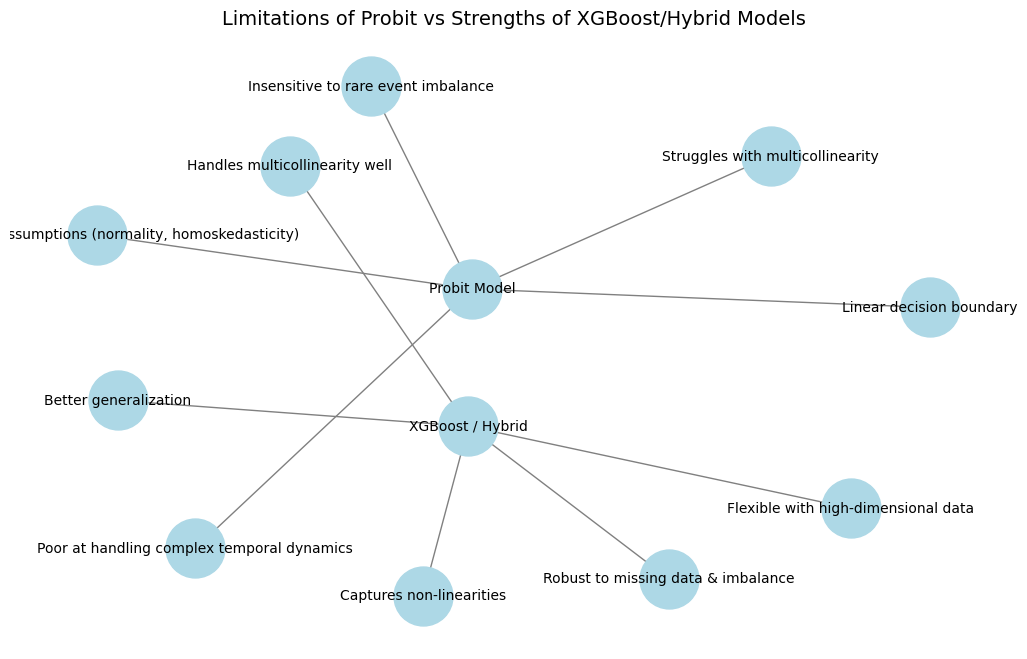

In [5]:
import matplotlib.pyplot as plt
import networkx as nx

# Define limitations of Probit
limitations = {
    "Probit Model": [
        "Linear decision boundary",
        "Poor at handling complex temporal dynamics",
        "Requires strict assumptions (normality, homoskedasticity)",
        "Struggles with multicollinearity",
        "Insensitive to rare event imbalance"
    ]
}

# Define strengths of alternatives
alternatives = {
    "XGBoost / Hybrid": [
        "Captures non-linearities",
        "Handles multicollinearity well",
        "Robust to missing data & imbalance",
        "Flexible with high-dimensional data",
        "Better generalization"
    ]
}


G = nx.DiGraph()

# Adding node 
for model, limits in limitations.items():
    for lim in limits:
        G.add_edge(model, lim)

for model, strengths in alternatives.items():
    for s in strengths:
        G.add_edge(model, s)

# Define positions
pos = nx.spring_layout(G, seed=42)

# Draw 
plt.figure(figsize=(13, 8))
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=1800)
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=15, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=10)

plt.title("Limitations of Probit vs Strengths of XGBoost/Hybrid Models", fontsize=14)
plt.axis('off')
plt.show()
